In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df=pd.read_csv("diabetes_prediction_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [6]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

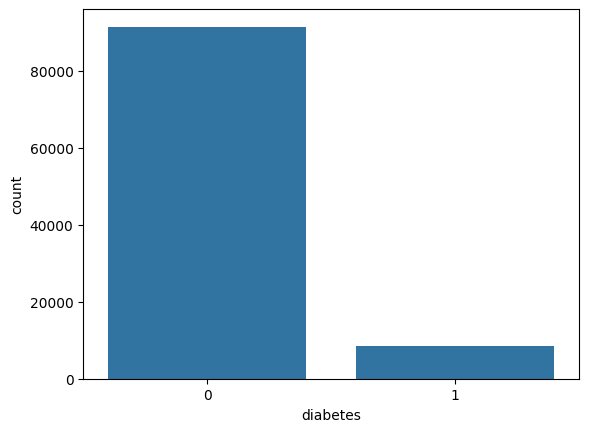

In [9]:
sns.countplot(x="diabetes",data=df)
plt.show()

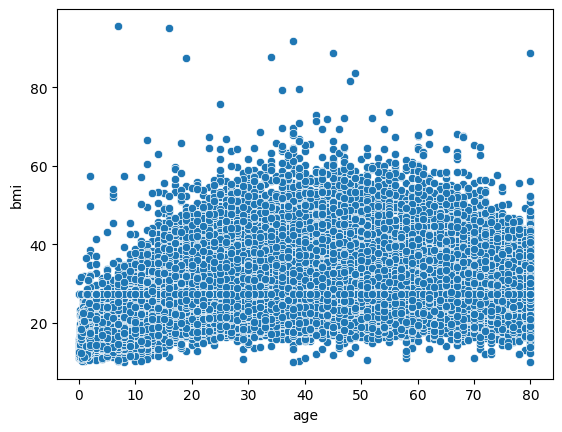

In [10]:
sns.scatterplot(x="age",y="bmi",data=df)
plt.show()

In [11]:
df=pd.get_dummies(df,drop_first=True)

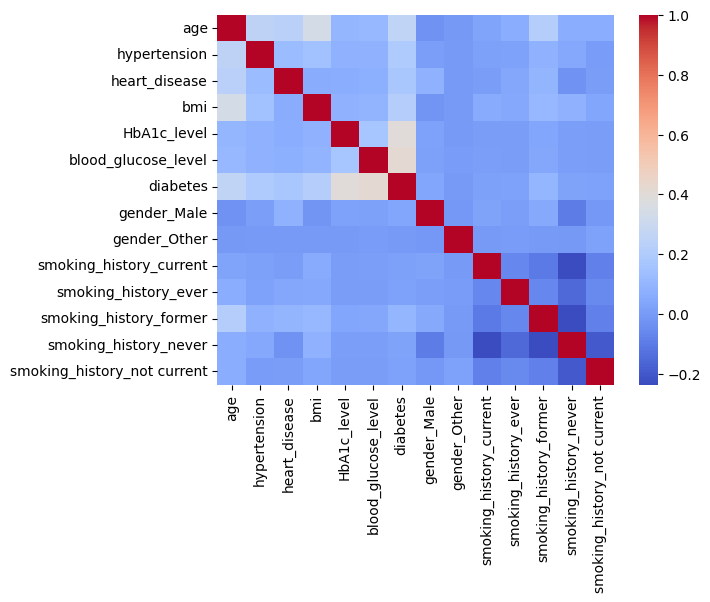

In [12]:
sns.heatmap(df.corr(),cmap="coolwarm")
plt.show()

In [13]:
x=df.drop(["diabetes"],axis=1)
y=df["diabetes"]

In [14]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [16]:
from sklearn.feature_selection import SelectKBest,f_classif
selector=SelectKBest(score_func=f_classif,k=5)
x_selected=selector.fit_transform(x,y)
selected_features = x.columns[selector.get_support()]
selected_features


Index(['age', 'hypertension', 'bmi', 'HbA1c_level', 'blood_glucose_level'], dtype='object')

In [15]:
from sklearn.model_selection import train_test_split,GridSearchCV
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.linear_model 

criterion :gini , Max_depth :None | Accuracy =0.95235


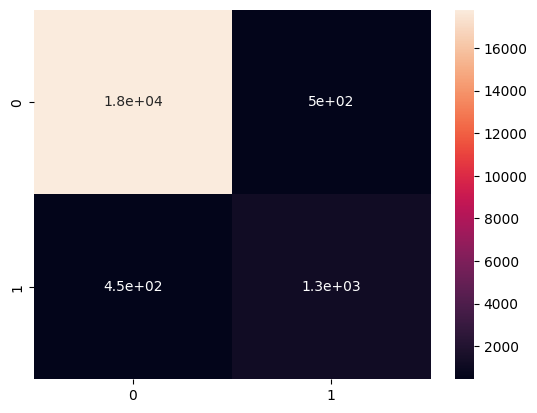

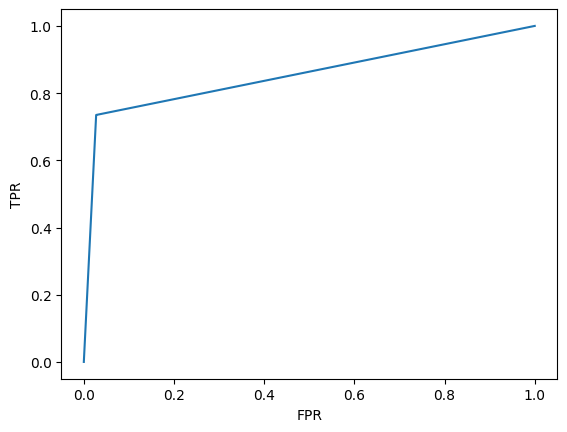

0.8538179402725804
criterion :gini , Max_depth :5 | Accuracy =0.97215


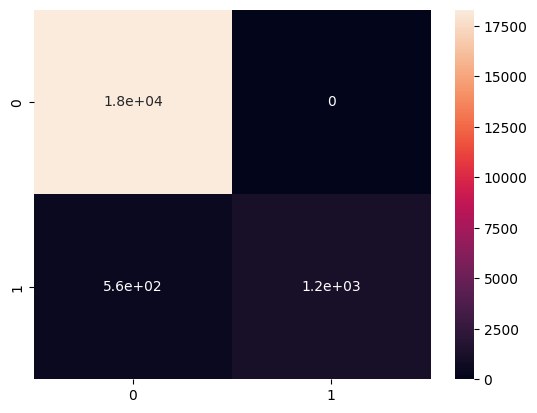

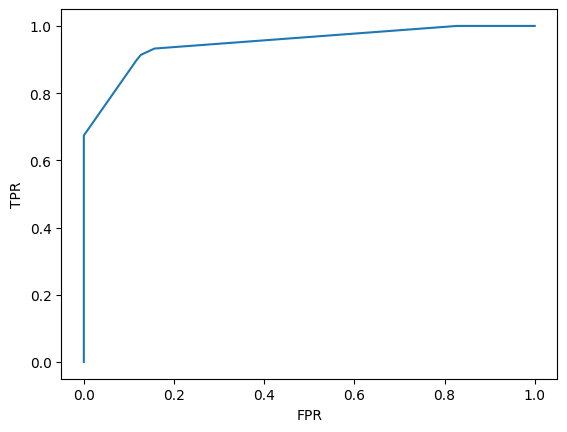

0.949171272964058
criterion :gini , Max_depth :8 | Accuracy =0.9722


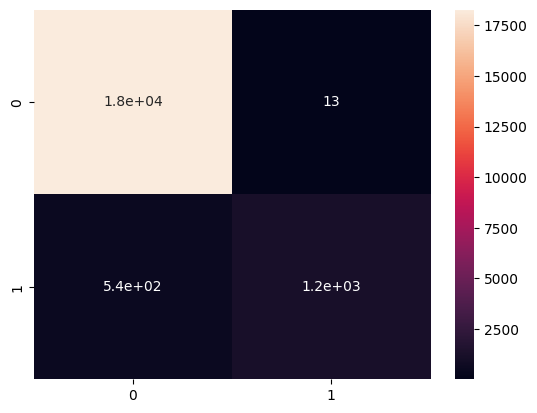

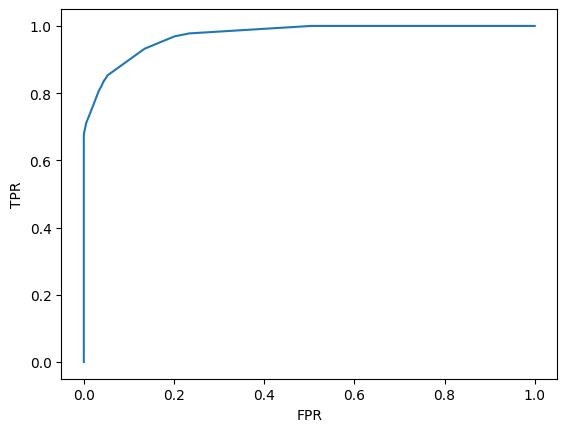

0.9723603432170601
criterion :gini , Max_depth :12 | Accuracy =0.971


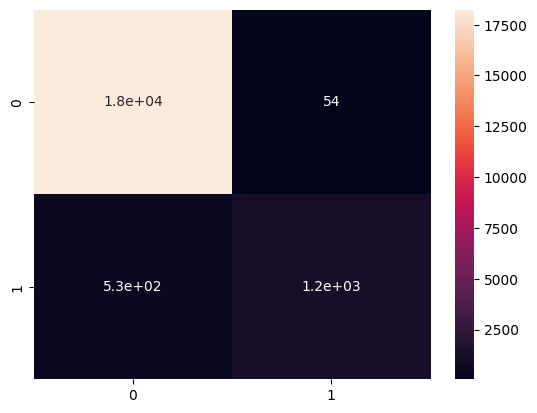

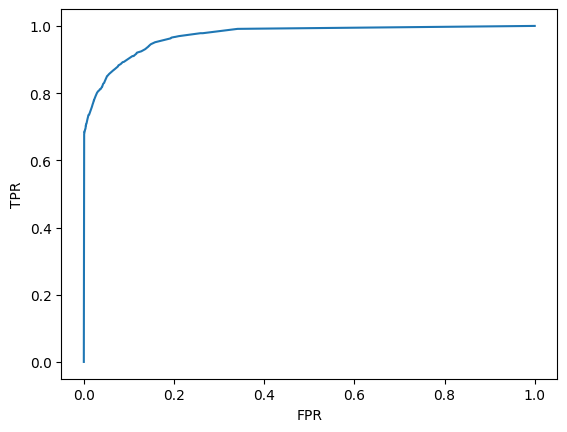

0.970746432066641
criterion :entropy , Max_depth :None | Accuracy =0.95225


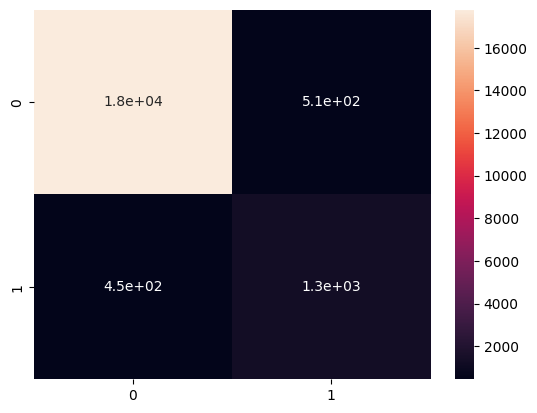

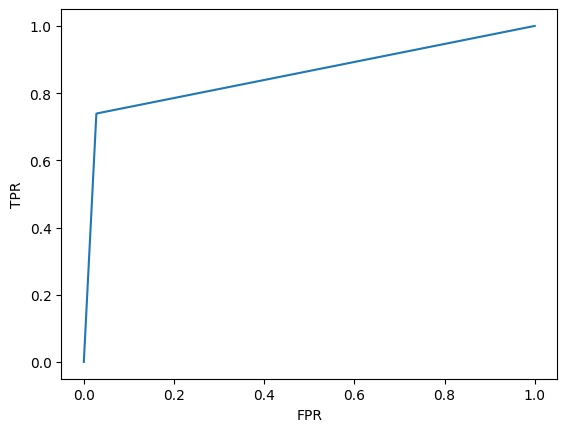

0.855695224643578
criterion :entropy , Max_depth :5 | Accuracy =0.97215


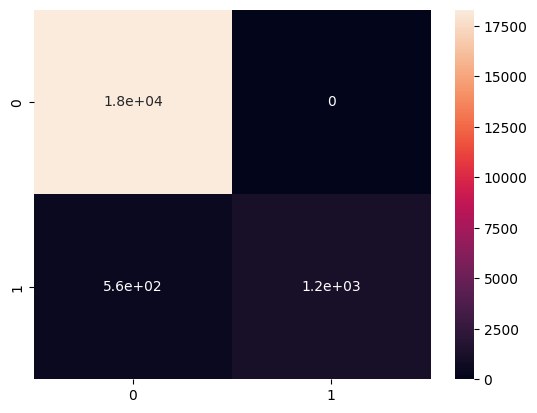

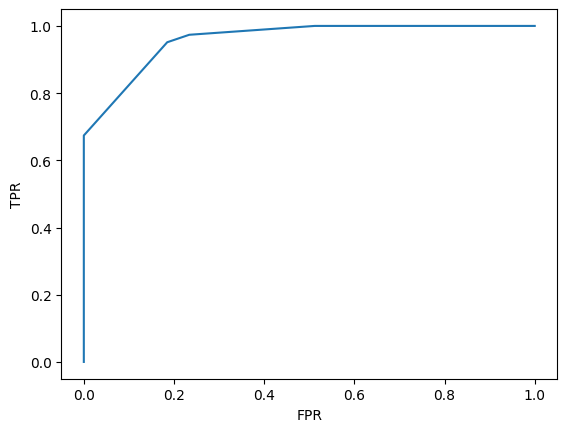

0.9598523157510916
criterion :entropy , Max_depth :8 | Accuracy =0.97215


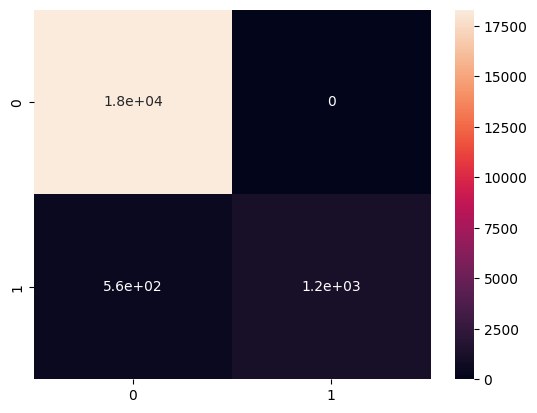

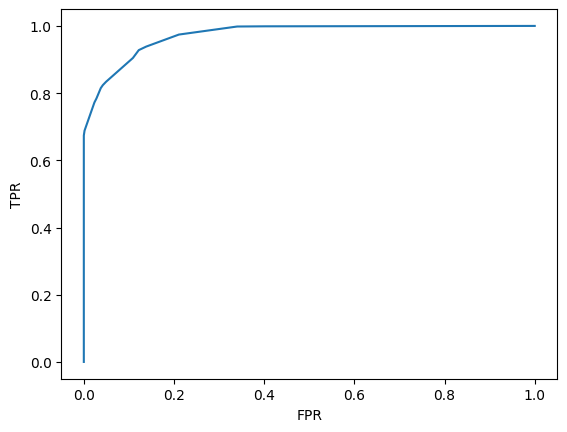

0.9732583599592559
criterion :entropy , Max_depth :12 | Accuracy =0.9715


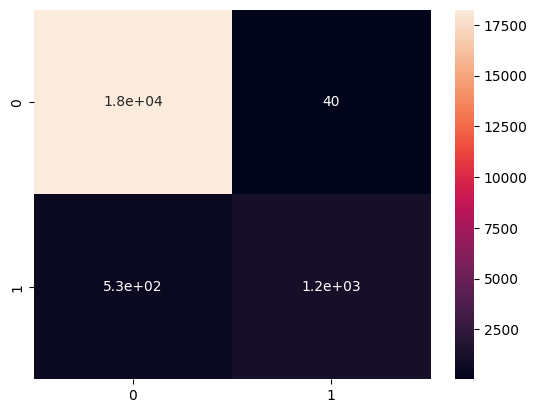

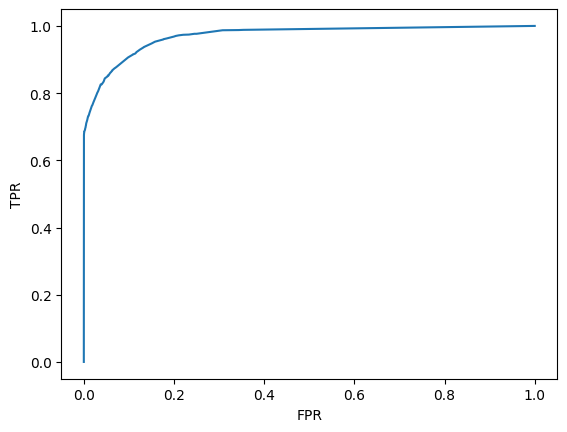

0.97052583678971


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,roc_curve,auc

criterion=['gini','entropy']
max_depth=[None,5,8,12]
for i in criterion:
    for j in max_depth:
        d=DecisionTreeClassifier(criterion=i,max_depth=j)
        d.fit(x_train,y_train)
        d_y_pred=d.predict(x_test)
        print(f"criterion :{i} , Max_depth :{j} | Accuracy ={accuracy_score(y_test,d_y_pred)}")
        cm=confusion_matrix(y_test,d_y_pred)
        sns.heatmap(cm,annot=True)
        plt.show()
        y_prob=d.predict_proba(x_test)[:,1]
        fpr,tpr,_=roc_curve(y_test,y_prob)
        a=auc(fpr,tpr)
        plt.plot(fpr,tpr)
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.show()
        print(a)
        

In [17]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,cross_val_score
dt=DecisionTreeClassifier()
dt_params={"criterion":['gini','entropy'],"max_depth":[None,5,8,10]}
grid=RandomizedSearchCV(estimator=dt,param_distributions=dt_params,cv=5,scoring="accuracy",n_jobs=-1,n_iter=5)
grid.fit(x_train,y_train)
print(grid.best_params_)
best=grid.best_estimator_
y_pred=best.predict(x_test)
print(accuracy_score(y_test,y_pred))

{'max_depth': 5, 'criterion': 'gini'}
0.97215


In [18]:
scores=cross_val_score(best,x_train,y_train,cv=5)
print(scores)

[0.9710625 0.971875  0.9725    0.97225   0.9713125]


In [14]:
from sklearn.decomposition import PCA
pca=PCA(0.95)
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
x_train=pca.fit_transform(x_train)
x_test=pca.transform(x_test)
print(x_train.shape)

(80000, 12)


/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ s

In [15]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,cross_val_score
dt=DecisionTreeClassifier()
dt_params={"criterion":['gini','entropy'],"max_depth":[None,5,8,10]}
grid=RandomizedSearchCV(estimator=dt,param_distributions=dt_params,cv=5,scoring="accuracy",n_jobs=-1,n_iter=5)
grid.fit(x_train,y_train)
print(grid.best_params_)
best=grid.best_estimator_
y_pred=best.predict(x_test)
print(accuracy_score(y_test,y_pred))

{'max_depth': 10, 'criterion': 'gini'}
0.9604


In [23]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC
models=[("svc",SVC(kernel="linear")),("knn",KNeighborsClassifier()),("naive",GaussianNB())]
stack=StackingClassifier(estimators=models,final_estimator=LogisticRegression(),n_jobs=-1)
stack.fit(x_train,y_train)
y_s_pred=stack.predict(x_test) 
print(accuracy_score(y_test,y_s_pred))

/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


0.96345


/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [19]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)


criterion :50 , Max_depth :0.01 | R2 =-0.09337415263503179


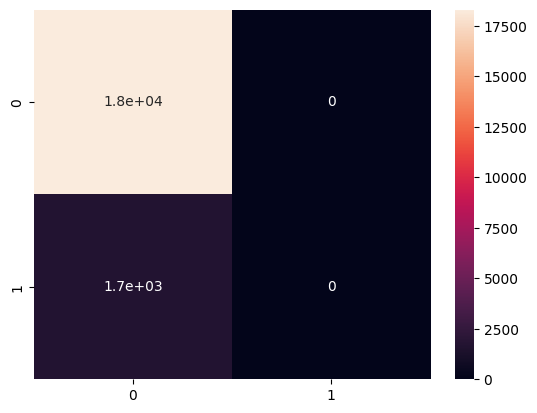

0.972131746080113


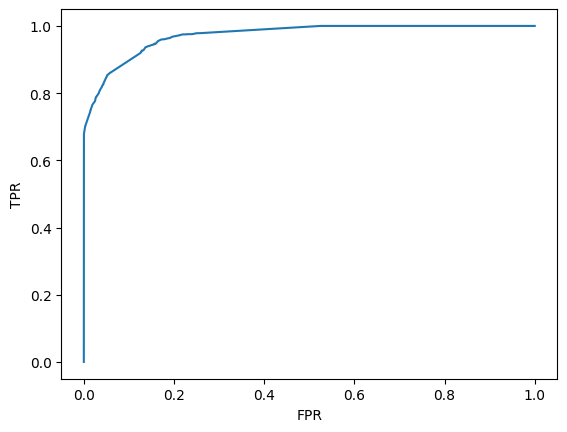

criterion :50 , Max_depth :0.1 | R2 =0.6466378616776712


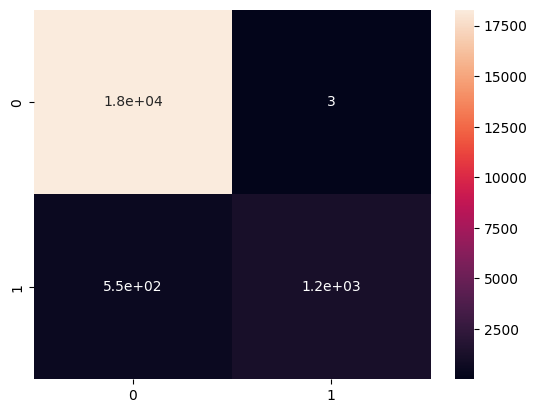

0.978478133285126


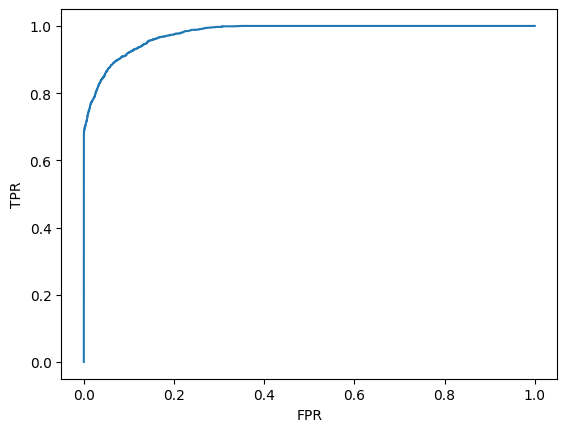

criterion :50 , Max_depth :1 | R2 =0.5794222375402718


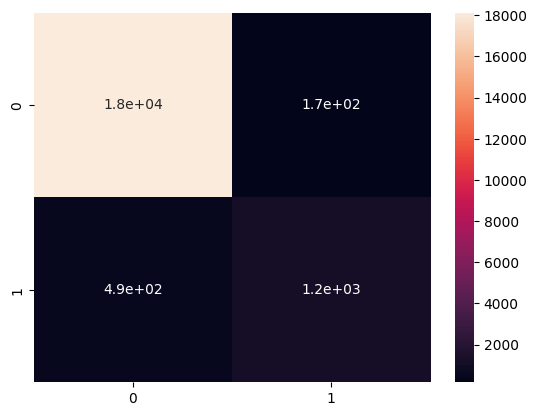

0.9735264382735237


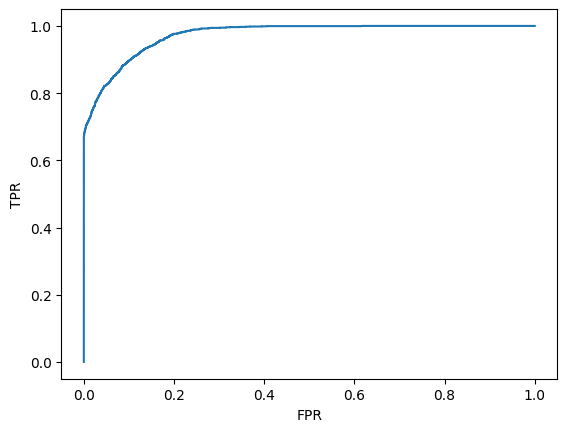

criterion :100 , Max_depth :0.01 | R2 =0.6434371176711284


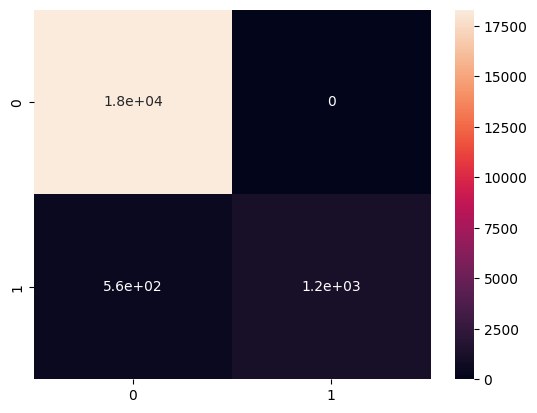

0.9743521502086118


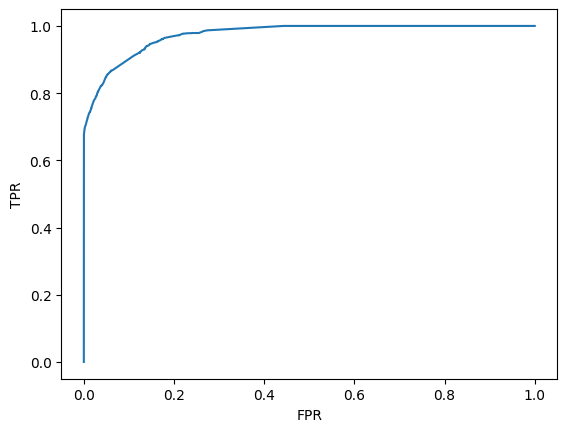

criterion :100 , Max_depth :0.1 | R2 =0.6479181592802884


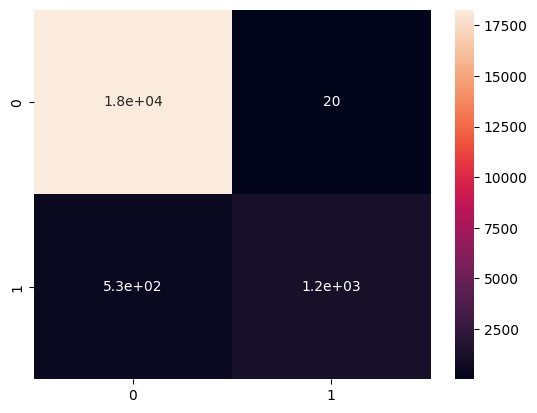

0.9798247663072787


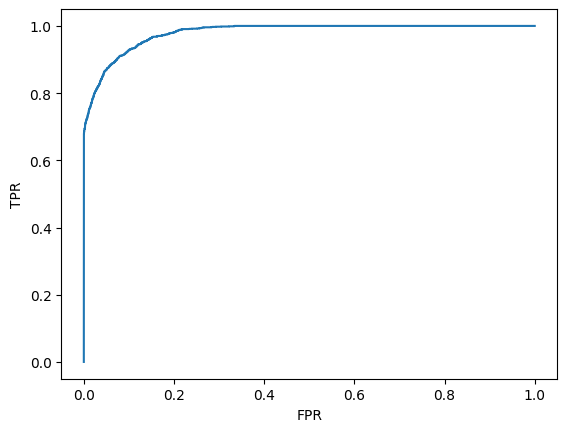

criterion :100 , Max_depth :1 | R2 =0.5608579223023233


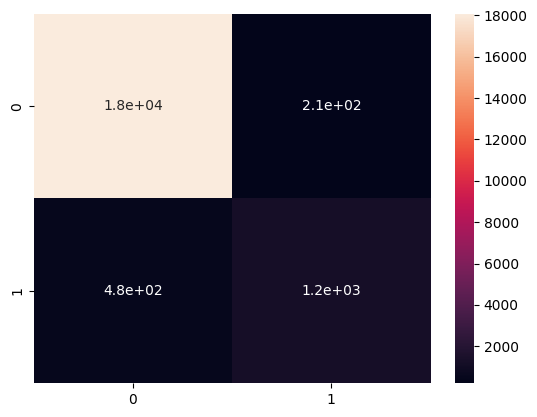

0.9718517930055806


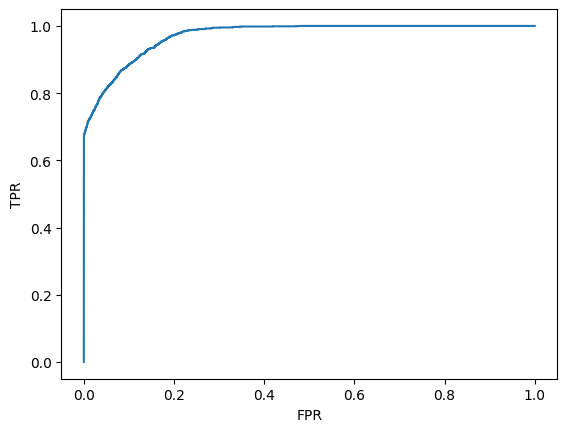

In [27]:
from xgboost import XGBClassifier

from sklearn.metrics import r2_score,confusion_matrix,roc_curve,auc
learning_rate=[0.01,0.1,1]
n_estimators=[50,100]
for i in n_estimators:
    for j in learning_rate:
        xg=XGBClassifier(n_estimators=i,learning_rate=j)
        xg.fit(x_train,y_train)
        xg_y_pred=xg.predict(x_test)
        print(f"criterion :{i} , Max_depth :{j} | R2 ={r2_score(y_test,xg_y_pred)}")
        cm=confusion_matrix(y_test,xg_y_pred)
        sns.heatmap(cm,annot=True)
        plt.show()
        y_prob_xg=xg.predict_proba(x_test)[:,1]
        fpr,tpr,_=roc_curve(y_test,y_prob_xg)
        a=auc(fpr,tpr)
        print(a)
        plt.plot(fpr,tpr)
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.show()
        
        
        
        
        

In [28]:
from sklearn.decomposition import PCA
pca=PCA(0.95)

scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

x_train_pca=pca.fit_transform(x_train)
x_test_pca=pca.transform(x_test)

print(x_train_pca.shape)

(80000, 12)


/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ s

criterion :50 , Max_depth :0.01 | R2 =-0.09337415263503179


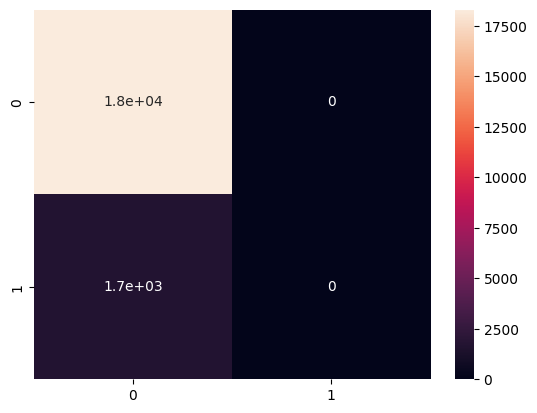

0.9546032396138415


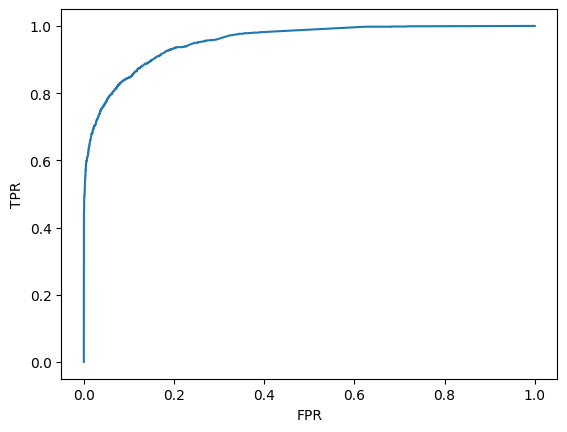

criterion :50 , Max_depth :0.1 | R2 =0.5435739046669921


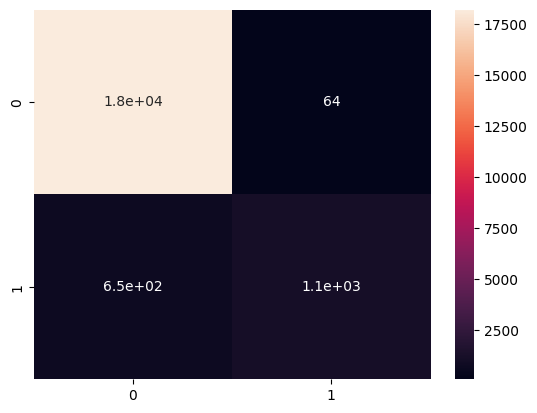

0.9676451671838215


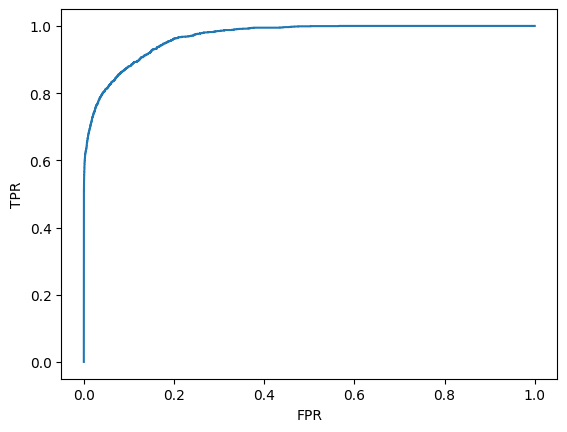

criterion :50 , Max_depth :1 | R2 =0.4763582805295925


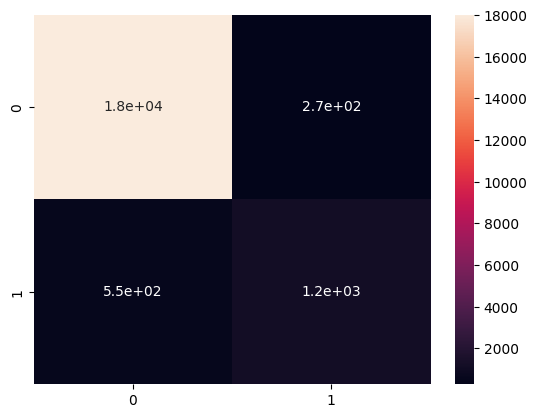

0.9593210722646058


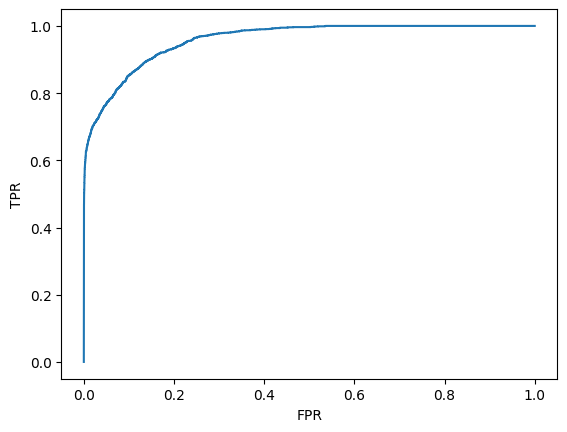

criterion :100 , Max_depth :0.01 | R2 =0.41298354920004443


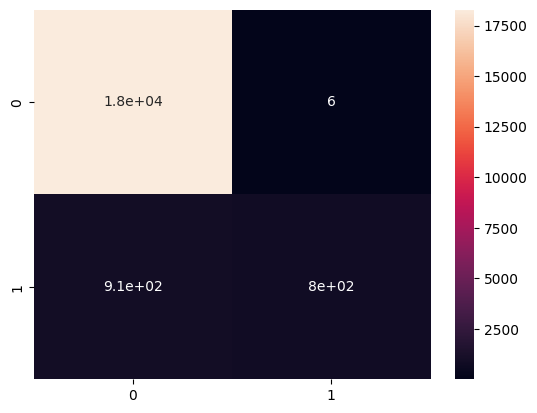

0.958228354264492


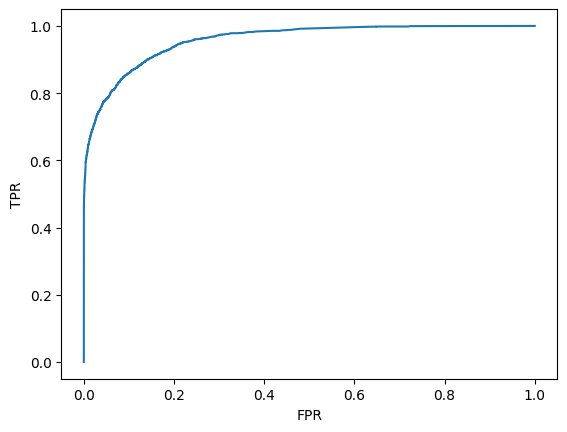

criterion :100 , Max_depth :0.1 | R2 =0.5634185175075577


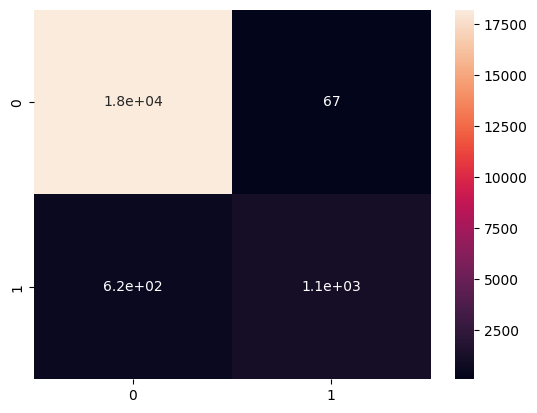

0.9702784352817243


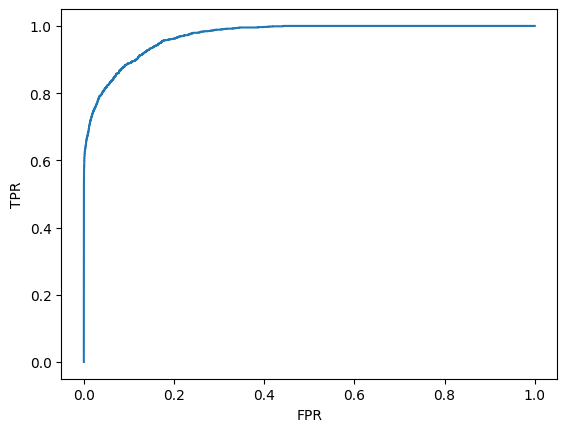

criterion :100 , Max_depth :1 | R2 =0.45267277488117563


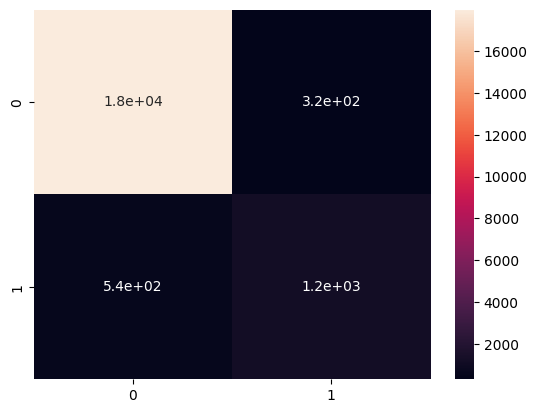

0.9586732416776814


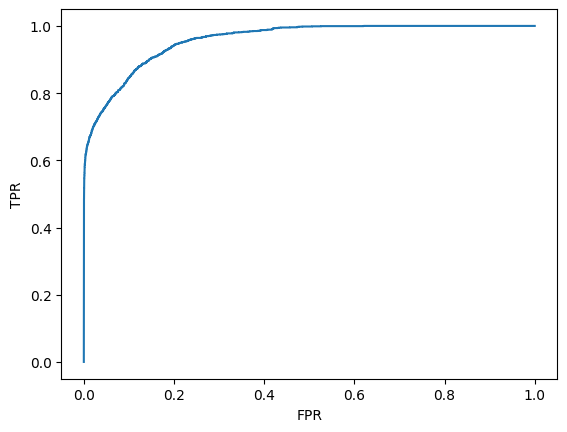

In [29]:
from xgboost import XGBClassifier

from sklearn.metrics import r2_score,confusion_matrix,roc_curve,auc
learning_rate=[0.01,0.1,1]
n_estimators=[50,100]
for i in n_estimators:
    for j in learning_rate:
        xg=XGBClassifier(n_estimators=i,learning_rate=j)
        xg.fit(x_train_pca,y_train)
        xg_y_pred=xg.predict(x_test_pca)
        print(f"criterion :{i} , Max_depth :{j} | R2 ={r2_score(y_test,xg_y_pred)}")
        cm=confusion_matrix(y_test,xg_y_pred)
        sns.heatmap(cm,annot=True)
        plt.show()
        y_prob_xg=xg.predict_proba(x_test_pca)[:,1]
        fpr,tpr,_=roc_curve(y_test,y_prob_xg)
        a=auc(fpr,tpr)
        print(a)
        plt.plot(fpr,tpr)
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.show()
        
        
        
    

In [3]:
from xgboost import XGBClassifier

In [2]:
!pip install xgboost

In [35]:
from sklearn.model_selection import GridSearchCV,cross_val_score,KFold
from sklearn.ensemble import GradientBoostingClassifier
gb=GradientBoostingClassifier()
gb_params={"learning_rate":[0.01,0.1],"max_depth":[5,8]}
grid=GridSearchCV(estimator=gb,param_grid=gb_params,cv=5,n_jobs=-1)
grid.fit(x_train,y_train)
print(grid.best_params_)
best_model=grid.best_estimator_
gb__pred=best_model.predict(x_test)
print(r2_score(y_test,gb__pred))

{'learning_rate': 0.01, 'max_depth': 5}
0.6434371176711284


In [37]:
from sklearn.model_selection import GridSearchCV,cross_val_score,KFold
scores=cross_val_score(best_model,x_train,y_train,cv=5)
print(scores)

[0.9710625 0.971875  0.9725    0.97225   0.9713125]


In [41]:
k=KFold(n_splits=5,shuffle=True,random_state=42)
for train_index,test_index in k.split(x):
    x_tr,x_te=x.iloc[train_index],x.iloc[test_index]
    y_tr,y_te=y.iloc[train_index],y.iloc[test_index]
    best_model.fit(x_tr,y_tr)
    pred=best_model.predict(x_te)
    print(r2_score(y_te,pred))
    

0.6434371176711284
0.6264085064091132
0.6365401184879216
0.6544941941649163
0.6304461308483835


In [20]:
from sklearn.model_selection import KFold

In [32]:
kf=KFold(n_splits=5, shuffle=True, random_state=None)
for train_index, test_index in kf.split(x):
        x_tr,x_te=x.iloc[train_index],x.iloc[test_index]
        y_tr,y_te=y.iloc[train_index],y.iloc[test_index]
        d.fit(x_tr,y_tr)
        y_pred_te=d.predict(x_te)
        print(accuracy_score(y_te,y_pred_te))
        

0.9714
0.9717
0.96875
0.97255
0.9696
